# M5 Forecasting - Exploratory Data Analysis

This notebook explores the M5 Forecasting dataset to understand:
- Data structure and dimensions
- Temporal patterns
- Product hierarchies
- Missing values and data quality

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path
sys.path.append('..')

from src.data.loader import M5DataLoader

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [5]:
# Load data
data_loader = M5DataLoader(data_path='../data/raw')
calendar, sales, prices = data_loader.load_all()

In [6]:
# Explore calendar data
print("Calendar Data:")
print(f"Shape: {calendar.shape}")
print(f"Date range: {calendar['date'].min()} to {calendar['date'].max()}")
print("\nColumns:", calendar.columns.tolist())
calendar.head()

Calendar Data:
Shape: (1969, 14)
Date range: 2011-01-29 00:00:00 to 2016-06-19 00:00:00

Columns: ['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [7]:
# Explore sales data
print("Sales Data:")
print(f"Shape: {sales.shape}")
print(f"Number of unique products: {sales['id'].nunique()}")
print("\nHierarchy:")
print(f"  Categories: {sales['cat_id'].nunique()}")
print(f"  Departments: {sales['dept_id'].nunique()}")
print(f"  Stores: {sales['store_id'].nunique()}")
print(f"  States: {sales['state_id'].nunique()}")
sales.head()

Sales Data:
Shape: (30490, 1919)
Number of unique products: 30490

Hierarchy:
  Categories: 3
  Departments: 7
  Stores: 10
  States: 3


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [8]:
# Reshape and visualize demand patterns
df = data_loader.create_base_dataset()
print(f"Combined dataset shape: {df.shape}")
df.head()

Combined dataset shape: (58327370, 22)


,id,item_id,dept_id,cat_id,store_id,state_id,demand,date,wm_yr_wk,weekday,...,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,3,2011-01-29,11101,Saturday,...,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,2.0
1,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,0,2011-01-30,11101,Sunday,...,2011,d_2,NaN,NaN,NaN,NaN,0,0,0,2.0
2,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,0,2011-01-31,11101,Monday,...,2011,d_3,NaN,NaN,NaN,NaN,0,0,0,2.0
3,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,1,2011-02-01,11101,Tuesday,...,2011,d_4,NaN,NaN,NaN,NaN,1,1,0,2.0
4,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,4,2011-02-02,11101,Wednesday,...,2011,d_5,NaN,NaN,NaN,NaN,1,0,1,2.0


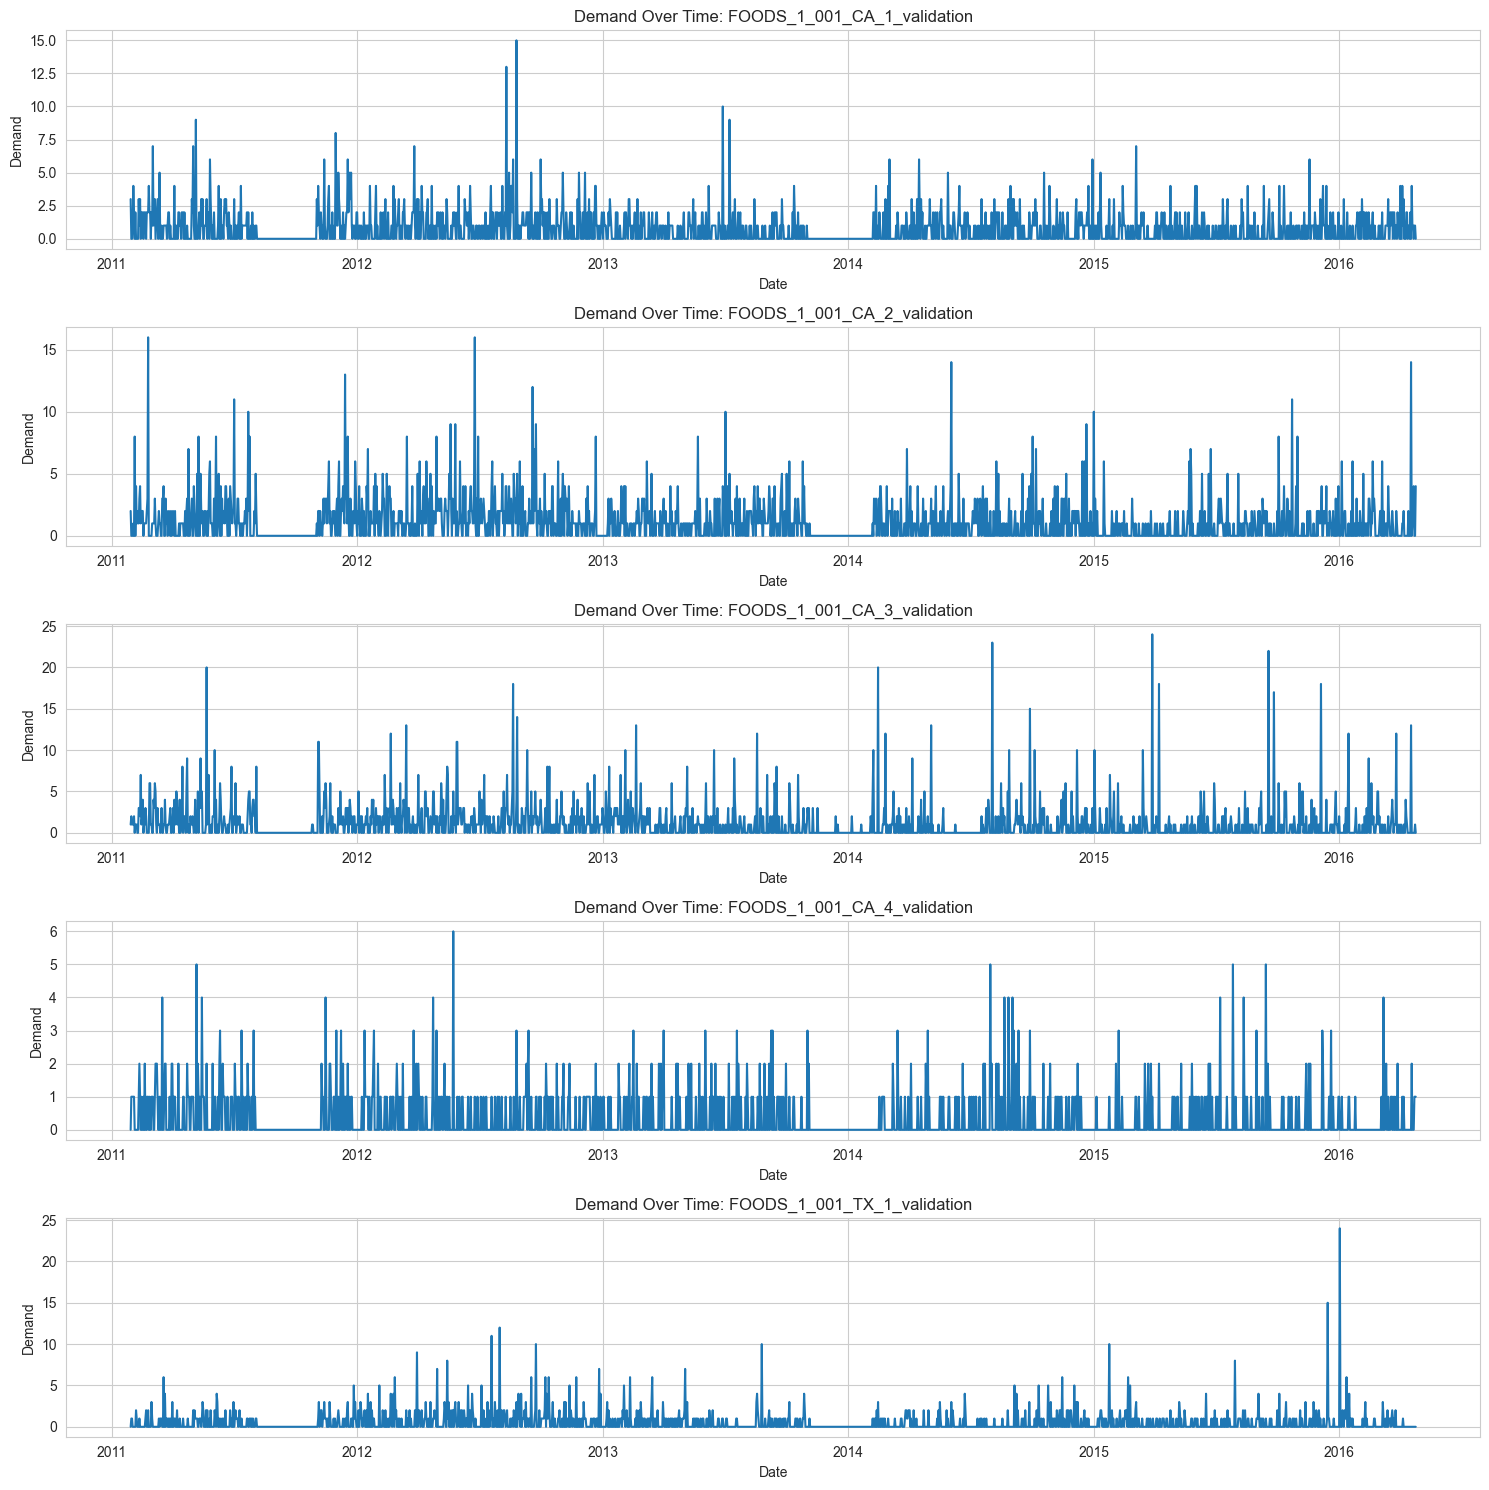

In [9]:
# Sample time series visualization
sample_ids = df['id'].unique()[:5]

fig, axes = plt.subplots(len(sample_ids), 1, figsize=(15, 3*len(sample_ids)))
if len(sample_ids) == 1:
    axes = [axes]

for idx, sample_id in enumerate(sample_ids):
    sample_data = df[df['id'] == sample_id].sort_values('date')
    axes[idx].plot(sample_data['date'], sample_data['demand'])
    axes[idx].set_title(f'Demand Over Time: {sample_id}')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Demand')
    axes[idx].grid(True)

plt.tight_layout()
plt.show()

/var/folders/l1/zg5krnsn45gc_5p05z_l5pfh0000gn/T/ipykernel_19490/1951650571.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_stats = df.groupby('cat_id')['demand'].agg(['mean', 'std', 'min', 'max'])


Demand Statistics by Category:
               mean       std  min  max
cat_id                                 
FOODS      1.640242  5.149802    0  763
HOBBIES    0.566668  2.036642    0  294
HOUSEHOLD  0.722981  2.086400    0  626


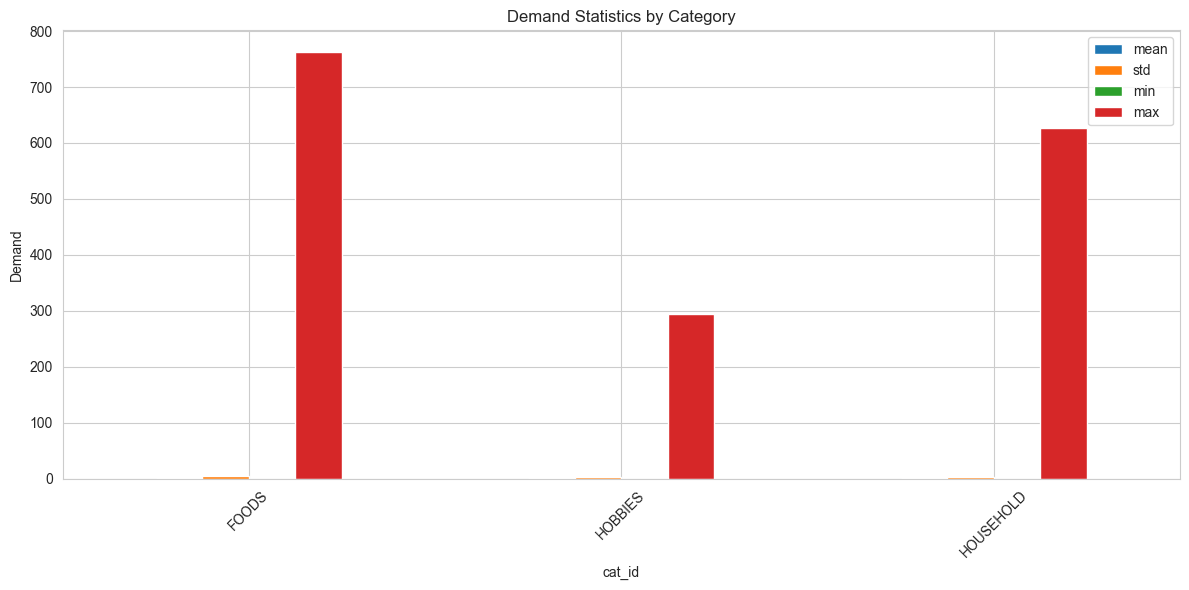

In [10]:
# Demand statistics by category
if 'cat_id' in df.columns:
    category_stats = df.groupby('cat_id')['demand'].agg(['mean', 'std', 'min', 'max'])
    print("Demand Statistics by Category:")
    print(category_stats)
    
    category_stats.plot(kind='bar', figsize=(12, 6))
    plt.title('Demand Statistics by Category')
    plt.ylabel('Demand')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()